# Bitcoin Tweets - Data Cleaning
**RMIT COSC 2671 / COSC 3047 - Assignment 2**

Source: `dataset/bitcoin_tweets_latest.csv` -> preprocessed into `dataset/bitcoin_tweets_clean.parquet`  
The parquet has 4,595,431 rows and 9 columns (355 MB, zstd compressed).  
This notebook loads the parquet, inspects it, and applies quality filters for downstream analysis.

## 1. Load the dataset

In [3]:
import ast
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("data/bitcoin_tweets_clean.parquet")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print()
print(df.dtypes)

Shape: (4595431, 9)
Columns: ['user_name', 'user_created', 'user_followers', 'user_friends', 'user_verified', 'date', 'text', 'hashtags', 'is_retweet']

user_name                      object
user_created      datetime64[us, UTC]
user_followers                  Int64
user_friends                    Int64
user_verified                 boolean
date              datetime64[us, UTC]
text                           object
hashtags                       object
is_retweet                    boolean
dtype: object


In [4]:
df.head(3)

,user_name,user_created,user_followers,user_friends,user_verified,date,text,hashtags,is_retweet
0,Merlin Doc 💥👌,2021-12-24 01:06:35+00:00,49,88,False,2025-03-06 14:42:53+00:00,all thieves will check my god thanks to you......,"['ledger', 'LedgerLiveApp', 'Bitcoin', 'BTC', ...",False
1,ángel Jácobo,2019-12-27 18:11:24+00:00,16,282,False,2025-03-06 14:42:56+00:00,This amazing faucet from @_bitcoiner is making...,"['Bitcoin', 'BTC', 'LN', 'LightningNetwork', '...",False
2,AR.eth,2021-12-13 11:03:02+00:00,26,164,False,2025-03-06 14:42:57+00:00,12. Examples of blockchains:\n\nBitcoin Networ...,"['BTC', 'ETH', 'SOL']",False


## 2. Why is `is_retweet` always False?

The raw CSV had two problems with this column:

1. **Broken rows** - tweet text containing unquoted commas shifted every column one position
   to the right, so values from `source` (e.g. `Twitter Web App`) and `hashtags`
   (e.g. `['BTC','Bitcoin',...]`) ended up in `is_retweet` instead. Those rows are
   dropped during preprocessing because a non-boolean `is_retweet` value is a reliable
   signal that the row is corrupt.

2. **Dataset was pre-filtered** - after removing broken rows, zero `RT @` tweets remain.
   The collector excluded retweets at source, so `is_retweet = False` everywhere is
   accurate, not a bug.

Because there are no retweets, the interaction network is built from **@mentions** in
tweet text instead.

In [5]:
rt_count = 0
for text in df["text"]:
    if text.startswith("RT @"):
        rt_count += 1

print("Tweets starting with 'RT @':", rt_count)
print("is_retweet unique values:", df["is_retweet"].unique().tolist())

Tweets starting with 'RT @': 0
is_retweet unique values: [False]


## 3. Extract @mentions for network construction

Each tweet where one user mentions another creates a directed edge in the interaction
network:

- **Node**: a Twitter user (`user_name`)
- **Edge**: `user_name` -> `mentioned_user`
- **Weight**: how many times that pair appears

In [6]:
MENTION_RE = re.compile(r"@(\w+)")

def extract_mentions(text):
    matches = MENTION_RE.findall(text)
    return [m.lower() for m in matches]


df["mentions"] = df["text"].apply(extract_mentions)

has_mention = df["mentions"].map(len) > 0
total_events = df["mentions"].map(len).sum()

print(f"Tweets with at least one @mention: {has_mention.sum():,} ({100 * has_mention.mean():.1f}%)")
print(f"Total mention events (edges before dedup): {total_events:,}")
print()
df.loc[has_mention, ["user_name", "mentions"]].head(5)

Tweets with at least one @mention: 1,681,948 (36.6%)
Total mention events (edges before dedup): 4,047,994



,user_name,mentions
0,Merlin Doc 💥👌,"[cryptosnox, nocasedyor, tanacrypto, cryptooua..."
1,ángel Jácobo,"[_bitcoiner, boltcoiner]"
3,Ajith,"[moodyowlnft, creo_engine, scapes_d]"
6,CaFiatEmptor,"[cakedefi, defichain, cakedefi]"
7,Ajith,"[nftshillmachine, creo_engine, cryptokaleo]"


In [7]:
# Explode so each (tweeter, mentioned user) pair is its own row
edges_raw = (
    df.loc[has_mention, ["user_name", "mentions", "date"]]
    .explode("mentions")
    .rename(columns={"user_name": "source", "mentions": "target"})
)

# Lowercase source so the same user under different casings is one node
edges_raw["source"] = edges_raw["source"].str.lower()

# Drop self-loops
edges_raw = edges_raw[edges_raw["source"] != edges_raw["target"]]

# Count how many times each (source, target) pair appears
edge_list = (
    edges_raw
    .groupby(["source", "target"], as_index=False)
    .size()
    .rename(columns={"size": "weight"})
    .sort_values("weight", ascending=False)
    .reset_index(drop=True)
)

print(f"Unique edges (source -> target pairs): {len(edge_list):,}")
print(f"Unique source nodes: {edge_list['source'].nunique():,}")
print(f"Unique target nodes: {edge_list['target'].nunique():,}")
print()
print("Top 10 most-mentioned users:")
edge_list.groupby("target")["weight"].sum().nlargest(10).to_frame()

Unique edges (source -> target pairs): 2,080,026
Unique source nodes: 327,076
Unique target nodes: 473,982

Top 10 most-mentioned users:


,weight
target,
elonmusk,68136
_bitcoiner,40747
boltcoiner,40545
cz_binance,35233
bscpitbull,34769
binance,34487
airdropinspect,30956
airdropstario,23921
saylor,21517


## 4. Account age from `user_created`

`user_created` is when the Twitter account was created. We use it as a proxy for
account legitimacy - older accounts are more likely to be real users.

The data shows every account is at least 2 years old (the collector filtered out
very new accounts). There are also 4 rows with a `1970-01-01` Unix epoch date
that predates Twitter and need to be dropped.

In [8]:
DATASET_START  = pd.Timestamp("2025-03-06", tz="UTC")
TWITTER_LAUNCH = pd.Timestamp("2006-03-21", tz="UTC")

# Drop rows where user_created predates Twitter
invalid = df["user_created"] < TWITTER_LAUNCH
print(f"Rows with invalid user_created date: {invalid.sum()}")
df = df[~invalid].copy()

df["account_age_days"] = (DATASET_START - df["user_created"]).dt.days

print(f"Remaining rows: {len(df):,}")
print()

age_years = df["account_age_days"] / 365
print("Account age at dataset start (years):")
print(age_years.describe().apply(lambda x: round(x, 2)))
print()

bins   = [0, 365*2, 365*3, 365*5, 365*10, float("inf")]
labels = ["<2 yr", "2-3 yr", "3-5 yr", "5-10 yr", ">10 yr"]
df["age_bucket"] = pd.cut(df["account_age_days"], bins=bins, labels=labels)

print("Tweet count by account age:")
print(df["age_bucket"].value_counts().sort_index())

Rows with invalid user_created date: 4
Remaining rows: 4,595,427

Account age at dataset start (years):
count    4595427.00
mean           6.42
std            3.96
min            2.15
25%            3.55
50%            4.43
75%            8.50
max           18.97
Name: account_age_days, dtype: float64

Tweet count by account age:
age_bucket
<2 yr            0
2-3 yr      409229
3-5 yr     2196132
5-10 yr    1035774
>10 yr      954292
Name: count, dtype: int64


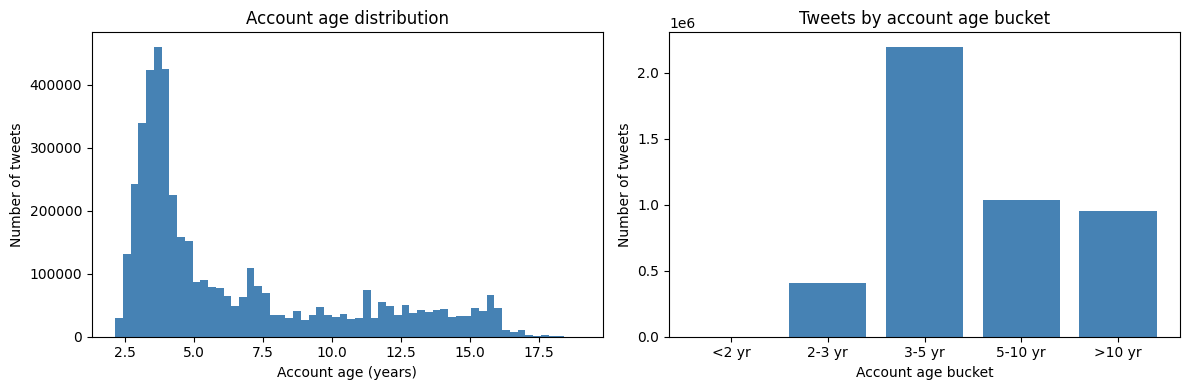

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

age_years = df["account_age_days"] / 365

axes[0].hist(age_years.dropna(), bins=60, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Account age (years)")
axes[0].set_ylabel("Number of tweets")
axes[0].set_title("Account age distribution")

bucket_counts = df["age_bucket"].value_counts().sort_index()
axes[1].bar(bucket_counts.index.astype(str), bucket_counts.values,
            color="steelblue", edgecolor="none")
axes[1].set_xlabel("Account age bucket")
axes[1].set_ylabel("Number of tweets")
axes[1].set_title("Tweets by account age bucket")

plt.tight_layout()
plt.show()

## 5. Spam and quality filters

Filters are applied in this order so each step feeds into the next:

| # | Filter | Rationale |
|---|---|---|
| 1 | Exact duplicate text | Same tweet posted repeatedly by bots |
| 2 | URL count > 1 | Two or more URLs in one tweet is almost always promotional |
| 3 | Hashtag count > 5 | Hashtag stuffing is a common spam signal |
| 4 | Spam keywords | Referrals, giveaways, airdrops, promo content |
| 5 | Text length < 30 | Too short to carry meaningful discussion |
| 6 | Near-duplicate text | Bot variants with slightly different handles or URLs |
| 7 | User volume > 100 | A single user posting hundreds of tweets is likely a bot |

In [10]:
def count_urls(text):
    """Count URLs by counting occurrences of 'http' in the text."""
    return text.count("http")


def count_hashtags(hashtag_str):
    """Count hashtags from a stringified Python list like "['btc', 'bitcoin']"."""
    if pd.isna(hashtag_str) or hashtag_str == "":
        return 0
    try:
        return len(ast.literal_eval(hashtag_str))
    except Exception:
        return len([h for h in hashtag_str.split(",") if h.strip()])


SPAM_KEYWORDS = [
    # Referral & signup
    "referral", "sign up", "signup", "refer a friend", "invite code",
    "promo code", "discount code", "coupon code", "use my code",
    
    # Free money / giveaway
    "get $", "free bitcoin", "free btc", "free crypto", "free money",
    "free tokens", "free coins", "free nft", "claim your",
    "giveaway", "giving away", "win bitcoin", "win btc",
    "airdrop", "air drop", "token sale", "presale", "pre-sale",
    
    # Earn / make money
    "makemoneyonline", "make money online", "earn bitcoin", "earn btc",
    "earn crypto", "earn daily", "earn passive", "passive income",
    "daily profit", "guaranteed profit", "guaranteed returns",
    "100x", "1000x", "get rich", "financial freedom",
    
    # Scam patterns
    "click here", "click the link", "link in bio", "link below",
    "limited time", "limited offer", "act now", "don't miss",
    "last chance", "expires soon", "only today",
    
    # Pump patterns
    "pump", "moonshot", "going to moon", "to the moon 🚀🚀",
    "next 100x", "next 1000x", "gem alert", "hidden gem",
    "buy now before", "don't sleep on",
    
    # Investment scams
    "double your", "triple your", "multiply your",
    "investment opportunity", "guaranteed", "risk free", "risk-free",
    "contact me", "dm me", "message me for",
    "whatsapp", "telegram group", "join our group", "join my group",
    
    # Exchange promotions
    "coinspot", "binance referral", "bybit referral", "kucoin referral",
    "okx referral", "bitget referral",
    
    # Generic spam
    "follow me", "follow us", "follow back", "followback",
    "retweet", "rt and follow", "like and follow",
    "check out my", "check my profile", "visit my",
    "buy followers", "boost your",
    
    # NFT spam
    "mint now", "nft drop", "nft launch", "whitelist spot",
    "opensea", "floor price", "nft giveaway",
    
    # idk what this means but it contains 48k spam tweets
    'sats'
]

def is_spam(text):
    """Return True if the tweet contains any known spam keyword."""
    text_lower = text.lower()
    for keyword in SPAM_KEYWORDS:
        if keyword in text_lower:
            return True
    return False


def strip_noise(text):
    """Remove URLs, hashtags, and mentions from text for near-duplicate comparison."""
    words = text.lower().split()
    clean_words = []
    for word in words:
        if not word.startswith("http") and not word.startswith("#") and not word.startswith("@"):
            clean_words.append(word)
    return " ".join(clean_words).strip()


def report(label, before, after):
    removed = len(before) - len(after)
    print(f"  {label:<30}  removed {removed:>8,}  |  remaining {len(after):>9,}")

In [11]:
start_n = len(df)
print(f"Starting rows: {start_n:,}\n")

# 1. Exact duplicate text
before = df.copy()
df = df.drop_duplicates(subset=["text"])
report("1. exact duplicate text", before, df)

# 2. URL density
df["url_count"] = df["text"].apply(count_urls)
before = df.copy()
df = df[df["url_count"] <= 1]
report("2. url_count > 1", before, df)

# 3. Hashtag stuffing
df["hashtag_count"] = df["hashtags"].apply(count_hashtags)
before = df.copy()
df = df[df["hashtag_count"] <= 5]
report("3. hashtag_count > 5", before, df)

# 4. Spam keywords
before = df.copy()
df = df[df["text"].apply(is_spam) == False]
report("4. spam keywords", before, df)

# 5. Text length
df["text_length"] = df["text"].str.len()
before = df.copy()
df = df[df["text_length"] >= 30]
report("5. text_length < 30", before, df)

# 6. Near-duplicate text (compare tweets after stripping URLs, hashtags, mentions)
df["text_stripped"] = df["text"].apply(strip_noise)
before = df.copy()
df = df.drop_duplicates(subset=["text_stripped"])
report("6. near-duplicate text", before, df)

# 7. High-volume users
tweet_counts = df["user_name"].value_counts()

print("\n  Top 10 users by tweet count (after filters so far):")
print(tweet_counts.head(10).to_string())
print()

for cap in [50, 100, 200, 500]:
    n_above  = (tweet_counts > cap).sum()
    pct      = 100 * tweet_counts[tweet_counts > cap].sum() / len(df)
    print(f"  cap = {cap:>4}:  {n_above:>5,} users above limit  ({pct:.1f}% of tweets)")

VOLUME_CAP  = 100
legit_users = tweet_counts[tweet_counts <= VOLUME_CAP].index
before = df.copy()
df = df[df["user_name"].isin(legit_users)]
report(f"7. user volume > {VOLUME_CAP}", before, df)

print(f"\nFinal rows:    {len(df):,}")
print(f"Total removed: {start_n - len(df):,}  ({100 * (1 - len(df) / start_n):.1f}% of input)")

Starting rows: 4,595,427

  1. exact duplicate text         removed  112,044  |  remaining 4,483,383
  2. url_count > 1                removed  562,594  |  remaining 3,920,789
  3. hashtag_count > 5            removed 1,334,231  |  remaining 2,586,558
  4. spam keywords                removed  270,946  |  remaining 2,315,612
  5. text_length < 30             removed   43,247  |  remaining 2,272,365
  6. near-duplicate text          removed  296,631  |  remaining 1,975,734

  Top 10 users by tweet count (after filters so far):
user_name
ExchangeWhales🐋                       21630
Bitcoin updates                       14279
ClankApp - Crypto Whales Tracker 🐳    13663
tictoknextblock                       12538
Bitcoin_Whale_Alert                   11439
DYOR.net                              10531
Bitcoin Bot🤖                          10227
Pandamn__it!!                          8044
Whale Alerts (Bitomic)                 7238
BEARWHALE 🐳                            6716

  cap =   50:  3,

## 6. Clean text for NLP

For sentiment analysis and topic modelling we want text without URLs, @mentions, and
hashtag symbols. The raw `text` column is kept as-is; `text_clean` holds the NLP version.

In [12]:
def clean_text_for_nlp(text):
    text = re.sub(r"http\S+", "", text)       # remove URLs
    text = re.sub(r"@\S+", "", text)           # remove mentions
    text = re.sub(r"#\S+", "", text)           # remove hashtags
    text = re.sub(r"\s+", " ", text).strip()   # collapse whitespace
    return text


df["text_clean"] = df["text"].apply(clean_text_for_nlp)

print(f"Rows with non-empty clean text: {(df['text_clean'].str.len() > 0).sum():,}")
print()
df[["text", "text_clean"]].sample(5)

Rows with non-empty clean text: 1,300,793



,text,text_clean
2363698,@MartyTalk Video games are a waste of time.\nI...,Video games are a waste of time. In 2011 I bou...
154191,@MartiniGuyYT #Bitcoin return on Investment is...,return on Investment is better than other mark...
2337849,@autumnbreezy13 #bitcoin allows everyone with ...,allows everyone with an internet connection to...
4186349,Happy Monday everybody\n#BTC gave me a nice se...,"Happy Monday everybody gave me a nice setup, g..."
971112,@Dennis_Porter_ Check out the Log scale model\...,Check out the Log scale model


#### Ghost account check

In [13]:
df[(df.user_followers == 0) & (df.user_friends == 0)][['user_name', 'user_followers', 'text_clean', 'user_friends']].sample(5)
print(f'total ghost accont tweets (0 friends and 0 followers): {len(df[(df.user_followers == 0) & (df.user_friends == 0)])}')

total ghost accont tweets (0 friends and 0 followers): 1618


texts actually looks clean, more informative than others

#### Minimum word count after cleaning 

In [14]:
df["word_count"] = df["text_clean"].str.split().str.len()

before = df.copy()
df = df[df["word_count"] >= 4]
report("word_count < 4", before, df)

  word_count < 4                  removed   66,941  |  remaining 1,233,853


The top users removed by filter 7 were whale trackers and price bots. But some of those bots post at lower volume and survive. Their tweets look like:

BTC $45,231 (+2.1%) | Volume: $28B | #Bitcoin #crypto

A simple signal: if text_clean (after removing URLs, hashtags, mentions) contains a $ followed by digits with no sentence-like content, it's probably automated.

In [15]:
PRICE_BOT_RE = re.compile(r"\$[\d,]+")

def looks_like_price_alert(text_clean):
    if not PRICE_BOT_RE.search(text_clean):
        return False
    # short cleaned text that's mostly a price quote
    words = text_clean.split()
    return len(words) < 8

before = df.copy()
df = df[df["text_clean"].apply(looks_like_price_alert) == False]
report("price alert bots", before, df)

  price alert bots                removed   11,425  |  remaining 1,222,428


In [16]:
import fasttext

# Load the pre-trained compressed model
model = fasttext.load_model("lid.176.ftz")


def get_languages_fasttext(text_list):
    # fasttext handles lists natively, which avoids Python loop overhead
    # Replace newlines because fasttext treats them as separate samples
    cleaned_texts = [str(text).replace("\n", " ") for text in text_list]

    # Predict in a single batch
    predictions = model.predict(cleaned_texts, k=1)

    # Extract the language code (e.g., '__label__en' -> 'en')
    # If the text was empty or invalid, default to 'unknown'
    langs = [
        pred[0].replace("__label__", "") if len(pred) > 0 else "unknown"
        for pred in predictions[0]
    ]
    return langs

before = df.copy()
# Convert column to list and process the entire batch at once
df["lang"] = get_languages_fasttext(df["text_clean"].tolist())

print(df["lang"].value_counts().head(10))
report("non en lang remove", before, df)

lang
en    1198576
de       4248
fr       2605
es       2106
ja       1840
it       1572
ru       1363
pt        735
nl        718
zh        659
Name: count, dtype: int64
  non en lang remove              removed        0  |  remaining 1,222,428


In [17]:
df[df.lang != 'en'].text.sample(5)

2317455    $ANY WE 🦍 TAKING TO $40🚀🚀 $gme $amc $spy $spce...
3772186    Are you still bullish on #Bitcoin And #Crypto ...
2650948    https://t.co/9Px1esc7oS\n😻⚕️THAT'S THE ABSOLUT...
1535003    🪙 $IOTX/USDT\n(Long)\nCross (20X)\n\nEntry Tar...
1216879    @TheMoonCarl 50 % #btc $btc - 30 % #crofam $cr...
Name: text, dtype: object

In [18]:
before = df.copy()
df = df[df["lang"] == "en"]
report("language != en", before, df)

  language != en                  removed   23,852  |  remaining 1,198,576


bot/hype content overuses emojis

In [19]:
import emoji

def count_emojis(text):
    return len([c for c in text if c in emoji.EMOJI_DATA])

df['emoji_count'] = df['text'].apply(count_emojis)

before = df.copy()
# Tweets with excessive emojis are almost always spam
df = df[df['emoji_count'] <= 5]
report("remove by excessive emoji count", before, df)

  remove by excessive emoji count  removed   17,084  |  remaining 1,181,492


Repetitive punctuation / shouting

In [20]:
# Excessive exclamation marks or question marks
df['exclaim_count'] = df['text'].apply(lambda x: x.count('!'))
df = df[df['exclaim_count'] <= 3]

# ALL CAPS words (shouting = hype/spam signal)
def caps_ratio(text):
    words = text.split()
    if len(words) == 0:
        return 0
    caps_words = [w for w in words if w.isupper() and len(w) > 2]
    return len(caps_words) / len(words)

before = df.copy()
df['caps_ratio'] = df['text'].apply(caps_ratio)
print(f'example removed tweet\n {df[df.caps_ratio >= 0.4].text.head(2)}')
df = df[df['caps_ratio'] <= 0.4]  # less than 40% all-caps words
report("remove by excessive emoji count", before, df)

example removed tweet
 111    #BTC LIMIT ORDER TO CATCH THE DUMP! https://t....
395    #Bitcoin is the only asset in the whole world ...
Name: text, dtype: object
  remove by excessive emoji count  removed   13,685  |  remaining 1,156,429


filter by meaningful word count

In [21]:
def meaningful_word_count(text):
    # Remove URLs, mentions, hashtags then count words
    cleaned = re.sub(r'http\S+|@\S+|#\S+', '', text).strip()
    return len(cleaned.split())

before = df.copy()
df['meaningful_words'] = df['text'].apply(meaningful_word_count)
print(f'example removed non meaningful tweets: {df[df.meaningful_words <=5].text.head(5)}')
df = df[df['meaningful_words'] >= 5]  # at least 5 real words
report("remove by meaningful word count", before, df)


example removed non meaningful tweets: 11            @TheMoonCarl Something huge is coming #BTC
131    @easyeight08 Yup so I can.....#BTC #ADA #COTI ...
201    Bitcoin BTC blockchain 🚀 #Btc #Eth #Sol #Doge ...
334    Btc long term benefits \n\n#btc https://t.co/z...
342            If you're buying #BTC here....kindly HMU.
Name: text, dtype: object
  remove by meaningful word count  removed   44,359  |  remaining 1,112,070


#### Remove any tweet containing a t.co link (The opinion is about the linked content, not Bitcoin itself)

In [22]:
before = df.copy()
df = df[~df['text'].str.contains(r'https://t\.co/', na=False)]
report("remove tweets containing link", before, df)

  remove tweets containing link   removed  479,891  |  remaining   632,179


Final column cleaning 

In [23]:
df = df.drop(columns=['meaningful_words', 'caps_ratio', 'exclaim_count', 'emoji_count', 
                      'lang', 'text_stripped', 'word_count', 'text_length','hashtag_count','is_retweet'])

In [24]:
def clean_and_parse_list(val):
    if not isinstance(val, str):
        return val
    
    # Clean up whitespace and outer quotes
    val = val.strip().strip('"').strip("'")
    
    # Fix the missing opening bracket if it got cut off (e.g., 'BTC'] )
    if val.endswith(']') and not val.startswith('['):
        val = '[' + val
        
    # Fix a missing closing bracket if it got cut off (e.g., ['Crypto', 'BTC )
    if val.startswith('[') and not val.endswith(']'):
        val = val + ']'
        
    # try to parse it
    try:
        return ast.literal_eval(val)
    except (SyntaxError, ValueError):
        # If it's still totally broken, return an empty list so it doesn't crash the code
        return []

df['hashtags'] = df['hashtags'].apply(clean_and_parse_list)

In [25]:
df.to_parquet('bitcoin_tweet.parquet')